# Conhecendo os dados

### Caracterização básica dos negócios disponíveis no Web para a cidade de Charlotte, USA.
### Este documento visa ilustrar recursos importantes em uma análise de dados.

In [2]:
#Análise e manipulação de dados 
import pandas as pd

#Visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt

#Recursos estatísticos
from scipy import stats

#Vizualização geoespacial
import folium
from folium.plugins import HeatMap

### Carregando os dados

In [3]:
# Caso esteja acessando na sua máquina
dfVenuesCharlotte = pd.read_csv('../data/venuesCharlotte.csv')


# Uso no google colab (usar essas linhas - reconhecer o seu drive e substituir o caminho abaixo)
'''from google.colab import drive
drive.mount('/content/drive')

#após a autorização, copie o caminho do arquivo no seu drive (ache o arquivo e clique com o botão direito)
#dfVenuesCharlotte = pd.read_csv('/content/drive/MyDrive/MineracaoDados/ConhecendoDados/venuesCharlotte.csv')
'''


"from google.colab import drive\ndrive.mount('/content/drive')\n\n#após a autorização, copie o caminho do arquivo no seu drive (ache o arquivo e clique com o botão direito)\n#dfVenuesCharlotte = pd.read_csv('/content/drive/MyDrive/MineracaoDados/ConhecendoDados/venuesCharlotte.csv')\n"

In [4]:
dfVenuesCharlotte


,_id,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,loc
0,5f8a33caf961c6b3e3c5f014,gnKjwL_1w79qoiV3IC_xQQ,Musashi Japanese Restaurant,"10110 Johnston Rd, Ste 15",Charlotte,NC,28210.0,35.092564,-80.859132,4.0,170,1,"{'GoodForKids': 'True', 'NoiseLevel': ""u'avera...","Sushi Bars, Restaurants, Japanese","{'Monday': '17:30-21:30', 'Wednesday': '17:30-...","{'type': 'Point', 'coordinates': [-80.859132, ..."
1,5f8a33caf961c6b3e3c5f01c,HhyxOkGAM07SRYtlQ4wMFQ,Queen City Plumbing,"4209 Stuart Andrew Blvd, Ste F",Charlotte,NC,28217.0,35.190012,-80.887223,4.0,4,1,"{'BusinessAcceptsBitcoin': 'False', 'ByAppoint...","Plumbing, Shopping, Local Services, Home Servi...","{'Monday': '7:0-23:0', 'Tuesday': '7:0-23:0', ...","{'type': 'Point', 'coordinates': [-80.8872232,..."
2,5f8a33caf961c6b3e3c5f028,irft4YkdNsww4DNf_Aftew,So Cool Frozen Yogurt,9020 B Albemarle Rd,Charlotte,NC,28227.0,35.210510,-80.690262,4.5,6,0,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Juice Bars & Smoothies, Food, Ice Cream & Froz...","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20...","{'type': 'Point', 'coordinates': [-80.690262, ..."
3,5f8a33caf961c6b3e3c5f02c,BvYU3jvGd0TJ7IyZdfiN2Q,Manzetti's Tavern,6401 Morrison Blvd,Charlotte,NC,28211.0,35.156338,-80.831878,3.5,16,0,"{'Alcohol': ""u'full_bar'"", 'BusinessAcceptsCre...","Sandwiches, Italian, American (Traditional), A...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'...","{'type': 'Point', 'coordinates': [-80.831878, ..."
4,5f8a33caf961c6b3e3c5f038,Qnz3ywR7BosTr8qDk6G-Pw,Mattress Firm Final Markdown,"13129 S Tryon St, Ste 120",Charlotte,NC,28278.0,35.100725,-80.992079,5.0,4,1,"{'RestaurantsPriceRange2': '2', 'BikeParking':...","Home & Garden, Mattresses, Home Decor, Furnitu...","{'Monday': '10:0-20:0', 'Tuesday': '10:0-20:0'...","{'type': 'Point', 'coordinates': [-80.99207916..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9504,5f8a33cff961c6b3e3c8dfee,UT22ExffDZjB1tzBDwSWfA,Rusty Bucket Restaurant & Tavern,4810 Ashley Park Ln,Charlotte,NC,28210.0,35.146186,-80.830284,3.5,109,1,"{'Alcohol': ""'full_bar'"", 'GoodForKids': 'True...","Restaurants, Bars, Nightlife, American (Tradit...","{'Monday': '11:0-23:0', 'Tuesday': '11:0-23:0'...","{'type': 'Point', 'coordinates': [-80.830284, ..."
9505,5f8a33cff961c6b3e3c8dff8,1Cz0gXFWdvtahHWlGe4lVQ,Raffi's Professional Detailing,NaN,Charlotte,NC,28277.0,35.020566,-80.830881,4.5,20,1,{'BusinessAcceptsCreditCards': 'True'},"Auto Detailing, Car Wash, Automotive, Wheel & ...","{'Monday': '9:0-18:0', 'Tuesday': '9:0-18:0', ...","{'type': 'Point', 'coordinates': [-80.83088055..."
9506,5f8a33cff961c6b3e3c8dffd,VqLfftBvRa4CrdcPGW26PA,Goodwill Industries of the Southern Piedmont,2122 Freedom Dr,Charlotte,NC,28208.0,35.233086,-80.875236,3.0,12,0,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Local Services, Community Service/Non-Profit","{'Monday': '8:0-16:0', 'Tuesday': '8:0-16:0', ...","{'type': 'Point', 'coordinates': [-80.8752355,..."
9507,5f8a33cff961c6b3e3c8e006,6Mrrb869fgDH7l5n4sDV8A,Gonzalez & Co. - Berkshire Hathaway,"3420 Toringdon Way, Ste 200",Charlotte,NC,28277.0,35.070155,-80.844360,5.0,3,1,"{'BusinessAcceptsCreditCards': 'False', 'Busin...","Home Services, Real Estate, Real Estate Agents","{'Monday': '9:0-18:0', 'Tuesday': '9:0-18:0', ...","{'type': 'Point', 'coordinates': [-80.8443602,..."


### Propriedades estatísticas

In [5]:
# exemplo de como calcular estatísticas básicas; média
dfVenuesCharlotte['stars'].mean()

3.5395940687769483

In [6]:
# exemplo de como calcular estatísticas básicas; variância
dfVenuesCharlotte['stars'].var()

1.0542009710880815

In [7]:
# exemplo de como calcular estatísticas básicas; desvio padrão
dfVenuesCharlotte['stars'].std()

1.0267428943450652

In [8]:
# exemplo de como calcular estatísticas básicas; median
dfVenuesCharlotte['stars'].median()

3.5

In [9]:
#quartil - 50%
dfVenuesCharlotte['stars'].quantile(q=0.50)


3.5

In [10]:
# resumo de estatísticas descritivas
dfVenuesCharlotte['stars'].describe()

count    9509.000000
mean        3.539594
std         1.026743
min         1.000000
25%         3.000000
50%         3.500000
75%         4.500000
max         5.000000
Name: stars, dtype: float64

In [12]:
#Correlações

dfIris = pd.read_csv('../data/Iris.csv').set_index('Id')
print(dfIris)

print(stats.pearsonr(dfIris['SepalLengthCm'], dfIris['SepalWidthCm']))

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
Id                                                                           
1              5.1           3.5            1.4           0.2     Iris-setosa
2              4.9           3.0            1.4           0.2     Iris-setosa
3              4.7           3.2            1.3           0.2     Iris-setosa
4              4.6           3.1            1.5           0.2     Iris-setosa
5              5.0           3.6            1.4           0.2     Iris-setosa
..             ...           ...            ...           ...             ...
146            6.7           3.0            5.2           2.3  Iris-virginica
147            6.3           2.5            5.0           1.9  Iris-virginica
148            6.5           3.0            5.2           2.0  Iris-virginica
149            6.2           3.4            5.4           2.3  Iris-virginica
150            5.9           3.0            5.1           1.8  I

In [13]:
# Matriz de correlação

corr = dfIris.iloc[:,0:4].corr()
corr


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


## Visualizações

<Axes: >

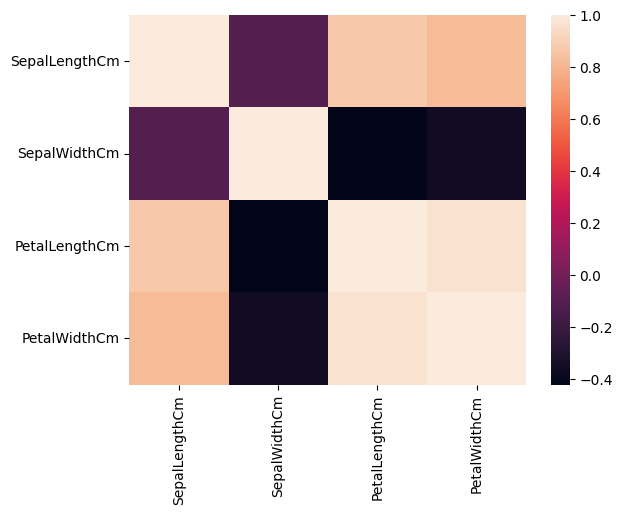

In [14]:
# Matriz de correlação (heatmap)

sns.heatmap(corr)

<Axes: >

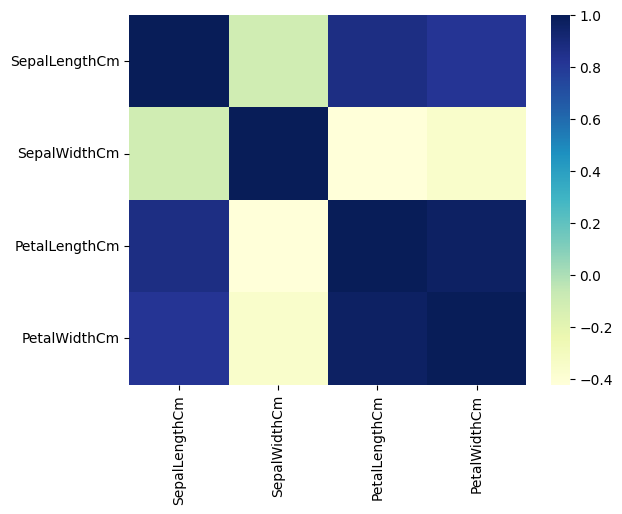

In [15]:
#Mudando o estilo de cores
sns.heatmap(corr, cmap="YlGnBu")


<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

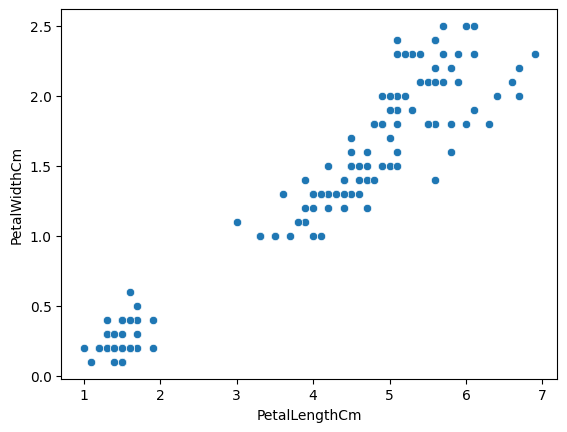

In [16]:
#Scatter plot

sns.scatterplot(data=dfIris, x="PetalLengthCm", y="PetalWidthCm")

<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

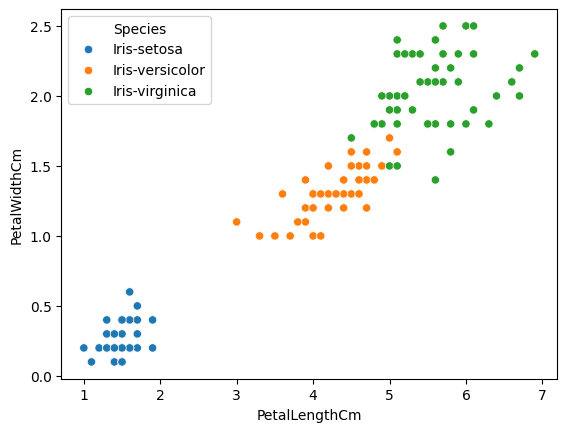

In [17]:
# Scatter plot - cores com classes
sns.scatterplot(data=dfIris, x="PetalLengthCm", y="PetalWidthCm", hue="Species")

<Axes: xlabel='stars', ylabel='Count'>

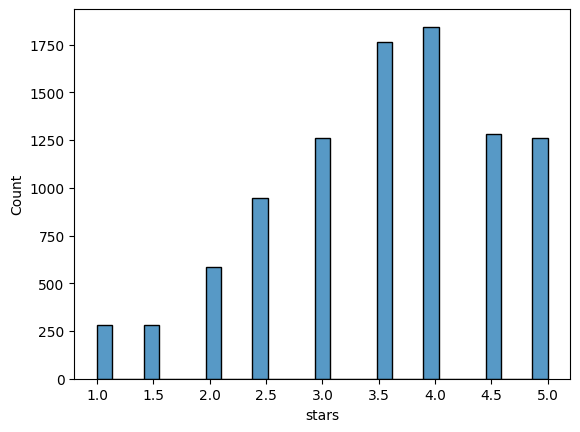

In [18]:
# histograma
sns.histplot(dfVenuesCharlotte['stars'])

<Axes: xlabel='stars', ylabel='Count'>

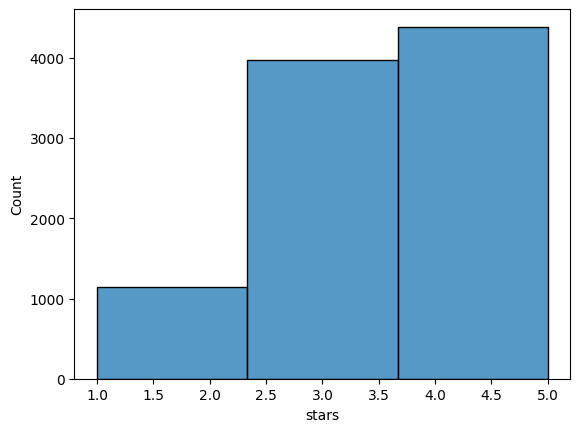

In [19]:
# histograma com bins específicos

sns.histplot(dfVenuesCharlotte['stars'],  bins=3)

<Axes: xlabel='stars', ylabel='Count'>

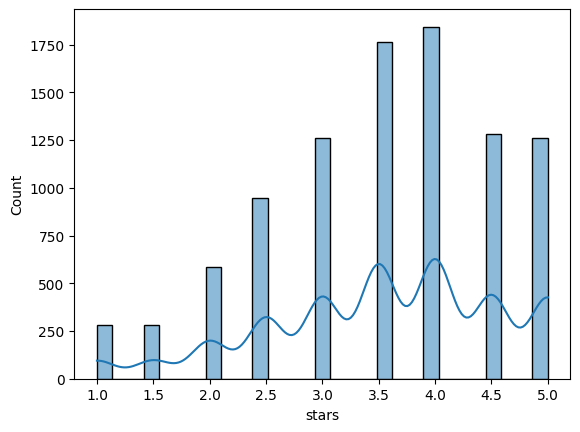

In [20]:
# histograma com KDE

sns.histplot(dfVenuesCharlotte['stars'],  kde=True)

<Axes: xlabel='review_count', ylabel='stars'>

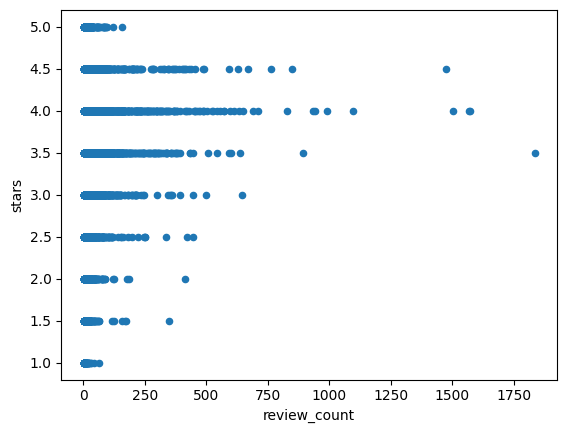

In [21]:
# Relação entre número de reviews e stars (ilustrando scatter plots)

dfVenuesCharlotte.plot.scatter(x='review_count', y='stars')

In [22]:

# Correlação de Pearson entre essas variáveis
stats.pearsonr(dfVenuesCharlotte['review_count'], dfVenuesCharlotte['stars'])


PearsonRResult(statistic=0.058466856310599, pvalue=1.1601961434327239e-08)

<Axes: xlabel='stars', ylabel='review_count'>

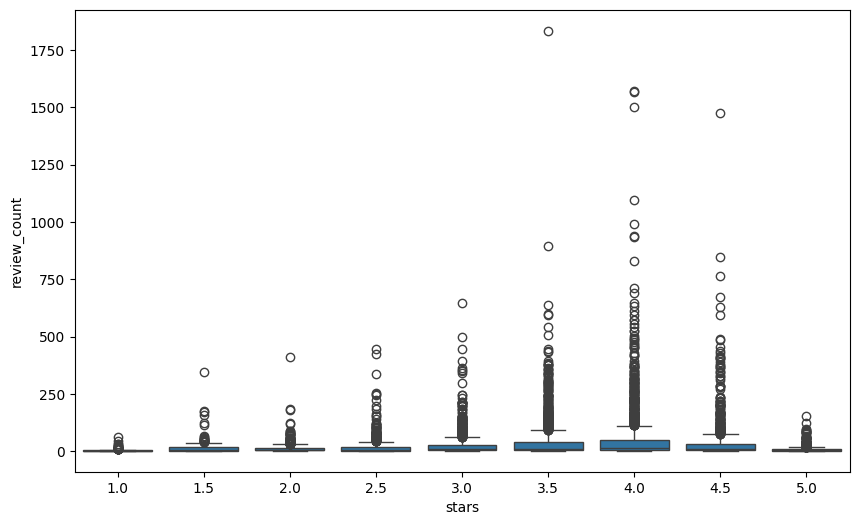

In [23]:
# Construção de boxplots

#controle do tamanho da visualização
plt.subplots(figsize=(10, 6))
sns.boxplot(y='review_count', x='stars', data=dfVenuesCharlotte)

<Axes: xlabel='stars', ylabel='review_count'>

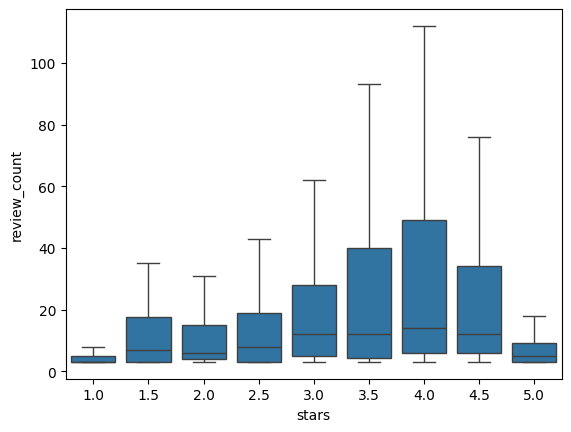

In [24]:
# Boxplots sem outliers para facilitar a visualização
sns.boxplot(y='review_count', x='stars', data=dfVenuesCharlotte, showfliers = False)

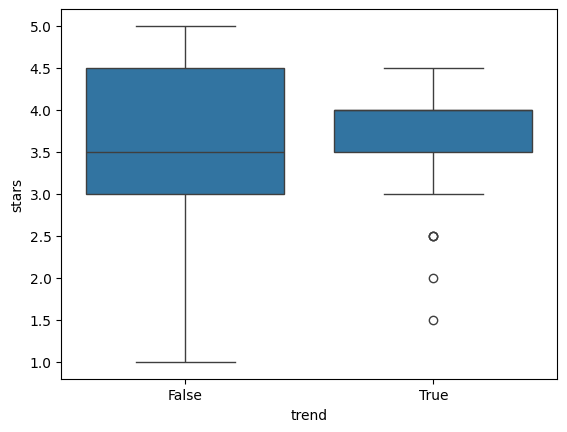

In [25]:
#Adicionando um novo atributio com base em um filtro
dfVenuesCharlotte['trend'] = dfVenuesCharlotte['review_count'] > 300


#Box plot stars vs popular (atributo criado com base em reviews)
fig = sns.boxplot(y='stars', x='trend', data=dfVenuesCharlotte, showfliers = True)

<Axes: ylabel='stars'>

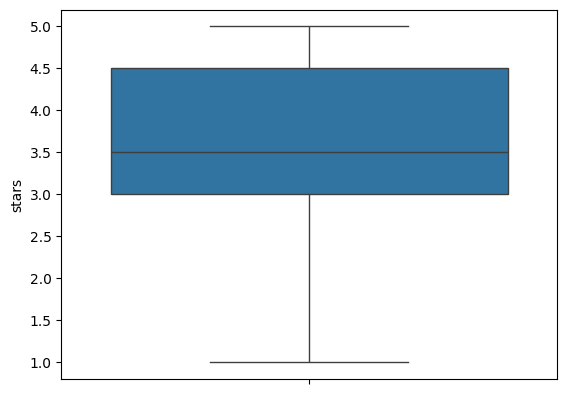

In [26]:
#Box plot de stars
sns.boxplot(data=dfVenuesCharlotte, y='stars')

<Axes: ylabel='stars'>

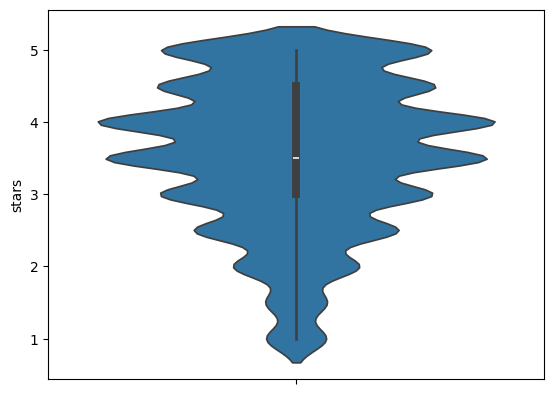

In [27]:
#Violin plot 
sns.violinplot(data=dfVenuesCharlotte, y='stars')

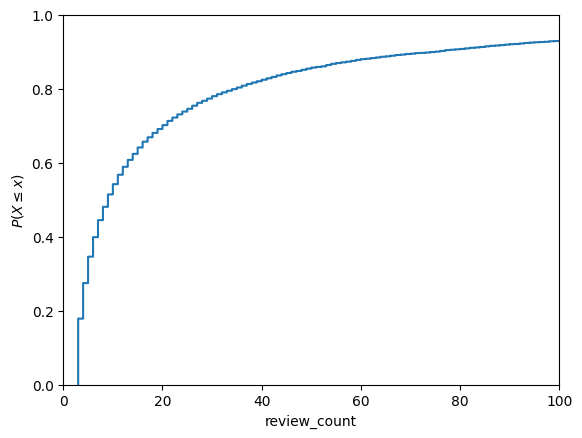

In [28]:
# CDF (cumulative distribution function)

ax = sns.ecdfplot(data = dfVenuesCharlotte, x='review_count')
ax.set(ylabel=r'$P(X \leq x)$')
plt.xlim([0, 100])
plt.show()

In [29]:
# Monstrando a localização dos pontos no mapa - necessário a biblioteca Folium

mapaCharlotte = folium.Map(location=[35.208764, -80.834679])
mapaCharlotte

In [ ]:
mapaCharlotte = folium.Map(location=[35.208764, -80.834679])

pontos  = [[row['latitude'],row['longitude']] for index, row in dfVenuesCharlotte.iterrows()]

HeatMap(pontos).add_to(mapaCharlotte)
mapaCharlotte

In [ ]:
#Curitiba
mapaCuritiba = folium.Map(location=[-25.423813, -49.263840])
mapaCuritiba

### Time series

In [3]:
#Dataset de reviews a ser analisado
dfreviewsCharlotte = pd.read_csv('../data/reviewsCharlotte.csv')
dfreviewsCharlotte

,_id,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,5f8a34d540d8c72bc76be7eb,44wcxT3D6xFtrol_sFJOWQ,698T9yypM-lneS0YBZHMzg,--EX4rRznJrltyn-34Jz1w,4.0,4,3,3,As I walked through Northlake Mall I was capti...,2017-09-03 19:54:51
1,5f8a34de40d8c72bc76f4590,K80y5FcyVOPRxLZz460fiQ,CR-ze9lR7fokp0fM8g5lYw,--EX4rRznJrltyn-34Jz1w,5.0,0,0,0,This store is always having some sort of sale....,2013-01-13 16:37:59
2,5f8a34df40d8c72bc76fbd76,vARVYVsu_j_8ccpYWcjCAw,dVy5EAV9YZIl9Xl-Xb1kHw,--EX4rRznJrltyn-34Jz1w,3.0,0,0,0,It's BBW what can I say?! This location is in ...,2014-12-13 02:04:34
3,5f8a34df40d8c72bc7706414,77OxSq5A67jbt87wI9gs_A,QPgXLWsDRplZilp2OciAiw,--EX4rRznJrltyn-34Jz1w,4.0,1,0,0,Great staff. Good products. Haven't been in on...,2010-02-26 21:24:15
4,5f8a343140d8c72bc7366941,G9BWOLXSqHblMdrX7GxXSA,M9RZJ4TTfYB2iosiEV30mg,--KCl2FvVQpvjzmZSPyviA,2.0,0,0,0,I waited the full wait time (40 min for my del...,2015-05-15 23:56:28
...,...,...,...,...,...,...,...,...,...,...
309420,5f8a344540d8c72bc73f916f,uuQKFV3EilT6IZ2oAEDIvg,ciXjBfJrAEteIKpzZg4I9g,zztHqd_3ULxuIS8lkhYdwg,4.0,1,1,2,"Beautiful, modem apartments with gorgeous view...",2018-04-06 12:53:22
309421,5f8a344a40d8c72bc74101d7,_0oqK_TQxKB52rEvTTsgZw,k24kSTpZHUdEd-QYXLy3fQ,zztHqd_3ULxuIS8lkhYdwg,5.0,0,0,0,Beautiful building with no stone unturned. Lov...,2018-01-26 00:10:05
309422,5f8a344c40d8c72bc7417c85,H7H4rKyMrRYyyQ08PdJxsQ,E3_yd2eBr9huZS6-ASMIeA,zztHqd_3ULxuIS8lkhYdwg,5.0,0,0,0,Thank you yelp for the event! Beautiful units ...,2018-01-26 01:00:04
309423,5f8a344d40d8c72bc741ca10,nYIWX_ArXSZeSJ4zpsLSqg,A4sS9Fo9iZykCNNxran4ZA,zztHqd_3ULxuIS8lkhYdwg,5.0,0,0,0,Truly the best place to call home in Uptown. T...,2018-03-20 22:13:58


In [6]:
from datetime import datetime

#Converte para datetime, depois acessa a hora e armazena em uma coluna específica - Note o uso do ".dt".
dfreviewsCharlotte['hour']=pd.to_datetime(dfreviewsCharlotte['date']).dt.hour

dfreviewsCharlotte

,_id,review_id,user_id,business_id,stars,useful,funny,cool,text,date,hour
0,5f8a34d540d8c72bc76be7eb,44wcxT3D6xFtrol_sFJOWQ,698T9yypM-lneS0YBZHMzg,--EX4rRznJrltyn-34Jz1w,4.0,4,3,3,As I walked through Northlake Mall I was capti...,2017-09-03 19:54:51,19
1,5f8a34de40d8c72bc76f4590,K80y5FcyVOPRxLZz460fiQ,CR-ze9lR7fokp0fM8g5lYw,--EX4rRznJrltyn-34Jz1w,5.0,0,0,0,This store is always having some sort of sale....,2013-01-13 16:37:59,16
2,5f8a34df40d8c72bc76fbd76,vARVYVsu_j_8ccpYWcjCAw,dVy5EAV9YZIl9Xl-Xb1kHw,--EX4rRznJrltyn-34Jz1w,3.0,0,0,0,It's BBW what can I say?! This location is in ...,2014-12-13 02:04:34,2
3,5f8a34df40d8c72bc7706414,77OxSq5A67jbt87wI9gs_A,QPgXLWsDRplZilp2OciAiw,--EX4rRznJrltyn-34Jz1w,4.0,1,0,0,Great staff. Good products. Haven't been in on...,2010-02-26 21:24:15,21
4,5f8a343140d8c72bc7366941,G9BWOLXSqHblMdrX7GxXSA,M9RZJ4TTfYB2iosiEV30mg,--KCl2FvVQpvjzmZSPyviA,2.0,0,0,0,I waited the full wait time (40 min for my del...,2015-05-15 23:56:28,23
...,...,...,...,...,...,...,...,...,...,...,...
309420,5f8a344540d8c72bc73f916f,uuQKFV3EilT6IZ2oAEDIvg,ciXjBfJrAEteIKpzZg4I9g,zztHqd_3ULxuIS8lkhYdwg,4.0,1,1,2,"Beautiful, modem apartments with gorgeous view...",2018-04-06 12:53:22,12
309421,5f8a344a40d8c72bc74101d7,_0oqK_TQxKB52rEvTTsgZw,k24kSTpZHUdEd-QYXLy3fQ,zztHqd_3ULxuIS8lkhYdwg,5.0,0,0,0,Beautiful building with no stone unturned. Lov...,2018-01-26 00:10:05,0
309422,5f8a344c40d8c72bc7417c85,H7H4rKyMrRYyyQ08PdJxsQ,E3_yd2eBr9huZS6-ASMIeA,zztHqd_3ULxuIS8lkhYdwg,5.0,0,0,0,Thank you yelp for the event! Beautiful units ...,2018-01-26 01:00:04,1
309423,5f8a344d40d8c72bc741ca10,nYIWX_ArXSZeSJ4zpsLSqg,A4sS9Fo9iZykCNNxran4ZA,zztHqd_3ULxuIS8lkhYdwg,5.0,0,0,0,Truly the best place to call home in Uptown. T...,2018-03-20 22:13:58,22


[Text(0.5, 0, 'Hora'), Text(0, 0.5, 'Reviews dos Usuários')]

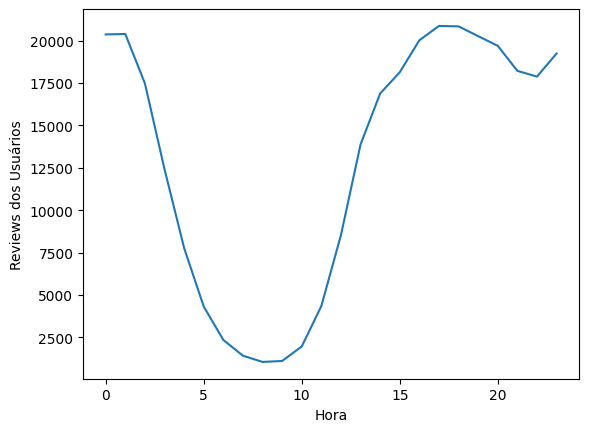

In [10]:
dfCountHour =dfreviewsCharlotte["hour"].value_counts().reset_index(name="Reviews")

ax = sns.lineplot(data=dfCountHour, x='hour',y='Reviews')
ax.set(xlabel='Hora', ylabel='Reviews dos Usuários')